# Game-24 GRPO sweep · cross-(model × length) report

Sweep: `logs/game24_sweep_exp4` — Qwen3-{0.6B, 1.7B, 4B} × max_completion_length {512, 1024}.

Each kernel below mirrors one figure from `game24_figure.ipynb` but combines all 6 configs onto a single panel, plus a printed `info` table to drive cross-model / cross-length comparison.

**Visual encoding everywhere**:
- color = model (0.6B blue, 1.7B teal, 4B red)
- linestyle = length (solid = 512, dashed = 1024)

**Two questions we want to answer at the end**:
1. Does a *bigger model* yield different rollout length / diversity / accuracy after training?
2. Does a larger *max_len* change rollout length / diversity / accuracy after training?

In [1]:
"""Setup: load eval_rollout.jsonl for every (model, length) cell."""
import json, warnings
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SWEEP_DIR = Path("logs/game24_sweep_exp4")
MODELS    = ["Qwen/Qwen3-0.6B", "Qwen/Qwen3-1.7B", "Qwen/Qwen3-4B"]
LENGTHS   = [512, 1024]

MODEL_SHORT = {"Qwen/Qwen3-0.6B": "0.6B", "Qwen/Qwen3-1.7B": "1.7B", "Qwen/Qwen3-4B": "4B"}
MODEL_COLOR = {"Qwen/Qwen3-0.6B": "#1f77b4", "Qwen/Qwen3-1.7B": "#2a9d8f", "Qwen/Qwen3-4B": "#e63946"}
LEN_LS      = {512: "-", 1024: "--"}

FIG_DIR = Path("manuscript/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name, dpi=200):
    out = FIG_DIR / name
    fig.savefig(out, dpi=dpi, bbox_inches="tight")
    print(f"  saved {out}")

def cfg_dir(model, L): return SWEEP_DIR / f"len{L}" / model.replace("/", "__")
def cfg_label(model, L): return f"{MODEL_SHORT[model]}/len{L}"

def load_eval(model, L):
    p = cfg_dir(model, L) / "eval_rollout.jsonl"
    if not p.exists():
        return None
    rows = [json.loads(l) for l in p.read_text().splitlines() if l.strip()]
    df = pd.DataFrame(rows)
    df["key"] = df["numbers"].apply(lambda x: tuple(sorted(x)))
    df["model"], df["max_len"] = model, L
    return df

DFS = {(m, L): load_eval(m, L) for m, L in product(MODELS, LENGTHS)}
for (m, L), d in DFS.items():
    tag = cfg_label(m, L)
    if d is None:
        print(f"  [missing]  {tag}")
    else:
        steps = sorted(d.global_step.unique())
        print(f"  {tag:>10s}  rollouts={len(d):>5d}  cycles={len(steps)}  steps={steps}")

CONFIGS = [(m, L) for (m, L), d in DFS.items() if d is not None]
FINAL_STEP = max(d.global_step.max() for d in DFS.values() if d is not None)
print(f"\nFINAL_STEP (used for end-of-training comparison): {FINAL_STEP}")

  0.6B/len512  rollouts= 4032  cycles=7  steps=[0, 200, 400, 600, 800, 1000, 1200]
  0.6B/len1024  rollouts= 4200  cycles=7  steps=[0, 200, 400, 600, 800, 1000, 1200]
  1.7B/len512  rollouts= 4032  cycles=7  steps=[0, 200, 400, 600, 800, 1000, 1200]
  1.7B/len1024  rollouts= 4200  cycles=7  steps=[0, 200, 400, 600, 800, 1000, 1200]
   4B/len512  rollouts= 4032  cycles=7  steps=[0, 200, 400, 600, 800, 1000, 1200]
  4B/len1024  rollouts= 4200  cycles=7  steps=[0, 200, 400, 600, 800, 1000, 1200]

FINAL_STEP (used for end-of-training comparison): 1200


In [2]:
"""Plot helpers: one curve per (model, length); small printed summary table at FINAL_STEP."""

# Global font bump for manuscript-grade figures.
plt.rcParams.update({
    "font.size":         14,
    "axes.titlesize":    16,
    "axes.titleweight":  "bold",
    "axes.labelsize":    14,
    "xtick.labelsize":   12,
    "ytick.labelsize":   12,
    "legend.fontsize":   13,
    "figure.titlesize":  17,
    "lines.linewidth":   2.2,
    "lines.markersize":  6,
})

def style(model, L):
    return dict(color=MODEL_COLOR[model], linestyle=LEN_LS[L], marker="o", ms=6, lw=2.2)

def cross_legend(ax, loc="best"):
    handles = ([plt.Line2D([],[], color=MODEL_COLOR[m], lw=2.5, label=MODEL_SHORT[m]) for m in MODELS]
               + [plt.Line2D([],[], color="k", linestyle=LEN_LS[L], lw=2.5, label=f"len{L}") for L in LENGTHS])
    ax.legend(handles=handles, loc=loc, fontsize=12, ncol=2, frameon=False)

def final_pivot(df_long, value_col, step_col="step"):
    """Take the FINAL_STEP row of df_long and pivot to model × length matrix."""
    sub = df_long[df_long[step_col] == FINAL_STEP].copy()
    return (sub.pivot_table(index="model_short", columns="max_len",
                            values=value_col, aggfunc="first")
                 .reindex(index=[MODEL_SHORT[m] for m in MODELS],
                          columns=LENGTHS))

def cross_summary(per_cfg_dict, label):
    """per_cfg_dict: {(model, L) -> scalar at FINAL_STEP}; print model×length matrix."""
    rows = []
    for m in MODELS:
        rows.append({"model": MODEL_SHORT[m],
                     **{f"len{L}": per_cfg_dict.get((m, L), float("nan")) for L in LENGTHS}})
    out = pd.DataFrame(rows).set_index("model")
    print(f"\n[{label} @ step={FINAL_STEP}]\n{out.round(3).to_string()}")
    return out

## Kernel 1 · Truncation / structural completeness

Mirrors `plot_truncation_stats` from `src.velo_viz`. We track three signals over training, all per (model, length):

- `mean_len` — mean CoT length (in tokens). Saturating at the cap implies truncation.
- `pct_parsable` — fraction with both `</think>` and `####` (structurally complete).
- `pct_correct` — fraction whose extracted expression evaluates to 24.

  saved manuscript/figures/game24-k1.png


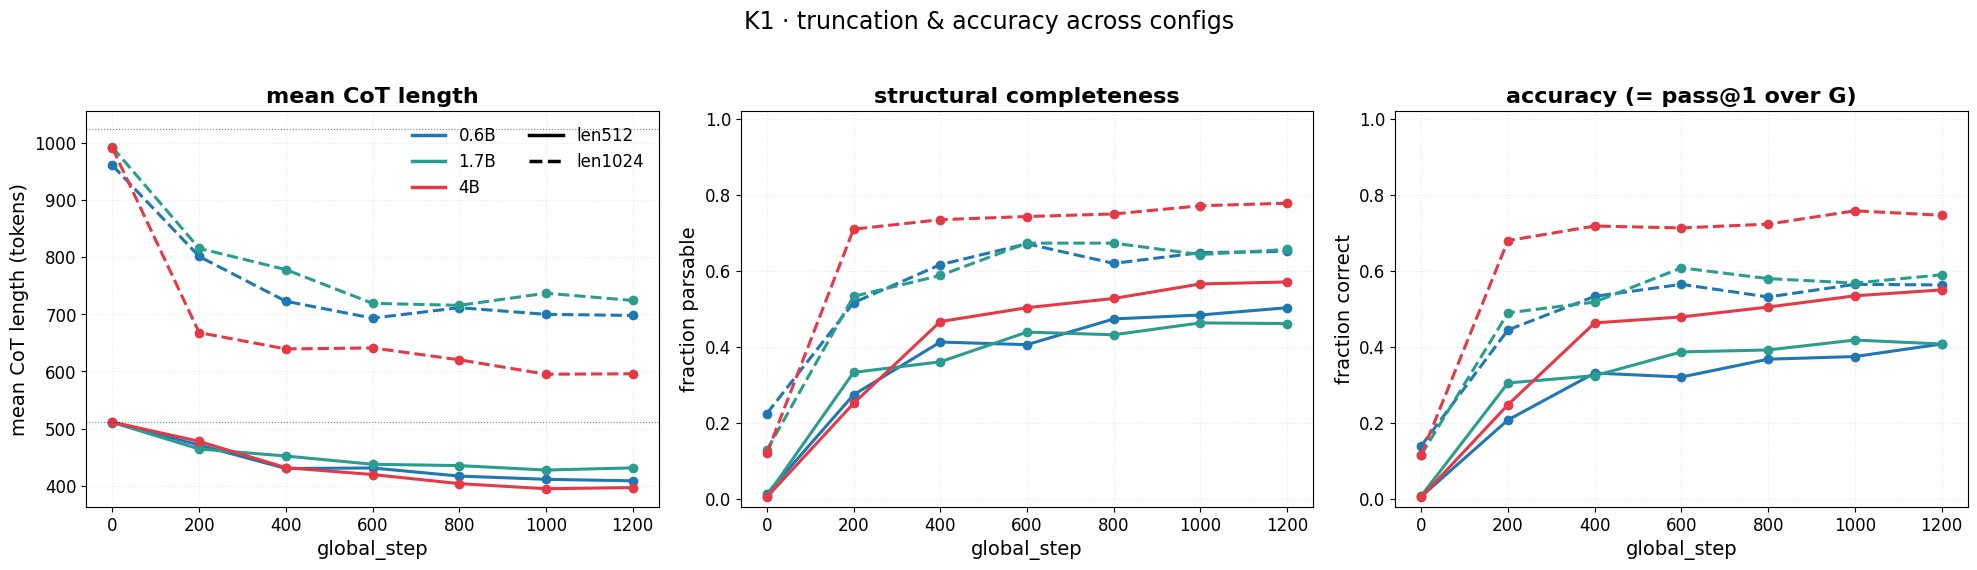

Per-cycle structural completeness, all configs (final step only):
model_short  max_len  mean_len  pct_truncated  pct_parsable  pct_correct
       0.6B      512   408.512          0.495         0.503        0.408
       0.6B     1024   698.045          0.348         0.652        0.563
       1.7B      512   431.184          0.538         0.462        0.408
       1.7B     1024   724.267          0.343         0.657        0.590
         4B      512   396.741          0.429         0.571        0.550
         4B     1024   595.937          0.222         0.778        0.747

[mean_len @ step=1200]
        len512  len1024
model                  
0.6B   408.512  698.045
1.7B   431.184  724.267
4B     396.741  595.937

[pct_parsable @ step=1200]
       len512  len1024
model                 
0.6B    0.503    0.652
1.7B    0.462    0.657
4B      0.571    0.778

[pct_correct @ step=1200]
       len512  len1024
model                 
0.6B    0.408    0.563
1.7B    0.408    0.590
4B      0.550    

In [3]:
from src.velo_viz import plot_truncation_stats

trunc = {}
for cfg in CONFIGS:
    fig, _, info = plot_truncation_stats(DFS[cfg], verbose=False); plt.close(fig)
    trunc[cfg] = info["by_step"].assign(model_short=MODEL_SHORT[cfg[0]], max_len=cfg[1])

fig, axes = plt.subplots(1, 3, figsize=(20, 5.6), sharex=True)
for cfg, by_step in trunc.items():
    m, L = cfg
    axes[0].plot(by_step.global_step, by_step.mean_len, **style(m, L))
    axes[1].plot(by_step.global_step, by_step.pct_parsable, **style(m, L))
    axes[2].plot(by_step.global_step, by_step.pct_correct, **style(m, L))
for L in LENGTHS:
    axes[0].axhline(L, color="k", lw=0.8, ls=":", alpha=0.5)
axes[0].set(xlabel="global_step", ylabel="mean CoT length (tokens)", title="mean CoT length")
axes[1].set(xlabel="global_step", ylabel="fraction parsable", title="structural completeness", ylim=(-0.02, 1.02))
axes[2].set(xlabel="global_step", ylabel="fraction correct", title="accuracy (= pass@1 over G)", ylim=(-0.02, 1.02))
for ax in axes:
    ax.grid(alpha=0.25, linestyle=":")
cross_legend(axes[0], loc="upper right")
fig.suptitle("K1 · truncation & accuracy across configs", y=1.02)
fig.tight_layout()
savefig(fig, "game24-k1.png")
plt.show()

long = pd.concat(trunc.values(), ignore_index=True).rename(columns={"global_step": "step"})
print("Per-cycle structural completeness, all configs (final step only):")
print(long[long.step == FINAL_STEP][["model_short", "max_len", "mean_len", "pct_truncated",
                                     "pct_parsable", "pct_correct"]]
          .round(3).to_string(index=False))

k1_info = {
    "mean_len_final":    cross_summary({c: trunc[c].set_index("global_step").mean_len.loc[FINAL_STEP]    for c in CONFIGS}, "mean_len"),
    "pct_parsable_final":cross_summary({c: trunc[c].set_index("global_step").pct_parsable.loc[FINAL_STEP] for c in CONFIGS}, "pct_parsable"),
    "pct_correct_final": cross_summary({c: trunc[c].set_index("global_step").pct_correct.loc[FINAL_STEP]  for c in CONFIGS}, "pct_correct"),
}

## Kernel 2 · CoT length & diversity

Mirrors `plot_length_and_diversity`. Three panels, each a curve per config:

- **mean_len** — same as K1 panel 1, here for reference.
- **mean_len split by correctness** — does training shorten *correct* rollouts (real reasoning compaction) or only *incorrect* ones (truncation hits)?
- **unique-CoT count per puzzle** — diversity within the G rollouts of a single puzzle, split by correctness.

  saved manuscript/figures/game24-k2.png


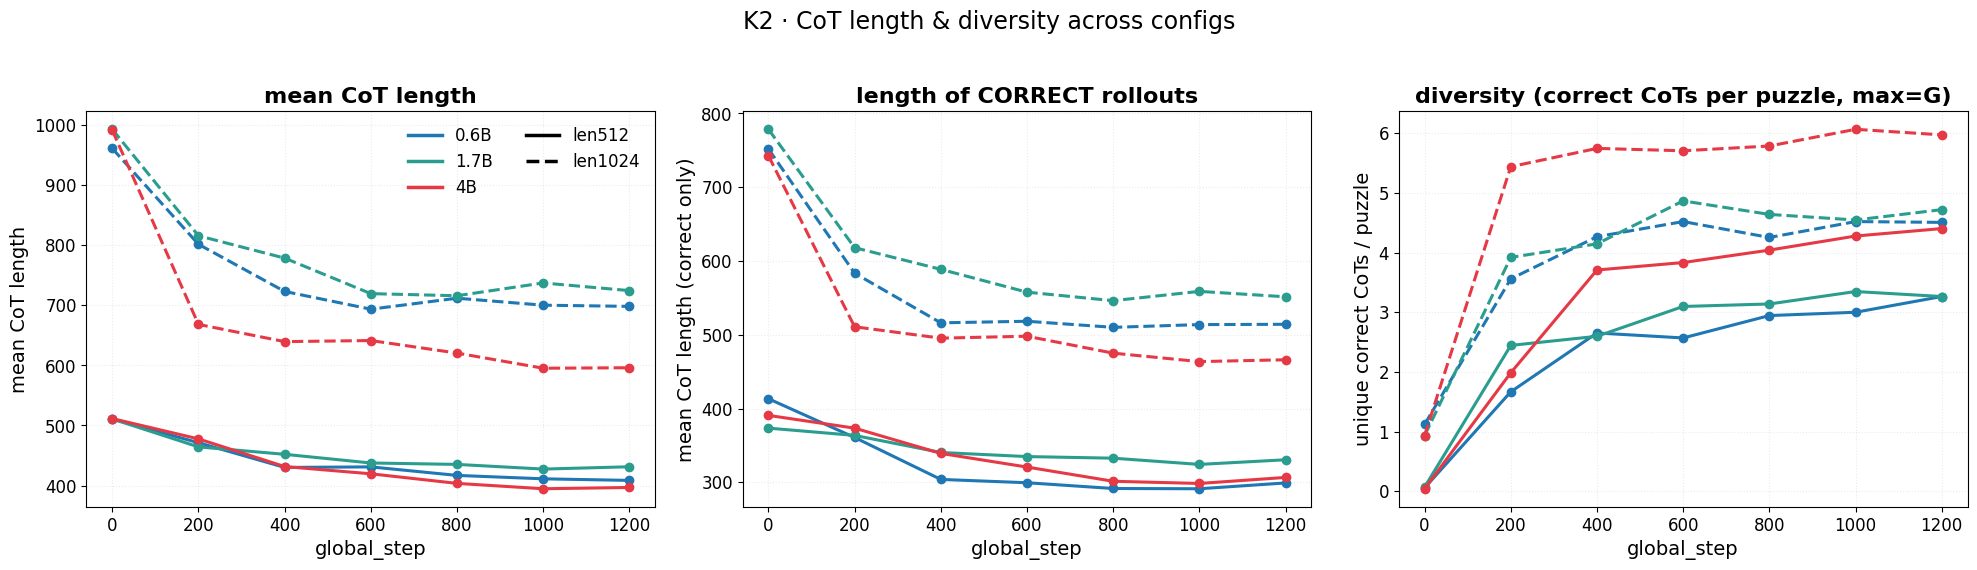


[mean_len @ step=1200]
        len512  len1024
model                  
0.6B   408.512  698.045
1.7B   431.184  724.267
4B     396.741  595.937

[mean_len(correct) @ step=1200]
        len512  len1024
model                  
0.6B   299.089  514.169
1.7B   330.485  551.446
4B     306.562  466.056

[mean_len(incorrect) @ step=1200]
        len512  len1024
model                  
0.6B   483.921  935.260
1.7B   500.581  972.959
4B     507.116  978.743

[uniq_correct/puzzle @ step=1200]
       len512  len1024
model                 
0.6B    3.264    4.507
1.7B    3.264    4.720
4B      4.403    5.973

[uniq_incorrect/puzzle @ step=1200]
       len512  len1024
model                 
0.6B    4.736    3.493
1.7B    4.736    3.280
4B      3.597    2.027


In [4]:
from src.velo_viz import plot_length_and_diversity

ld = {}
for cfg in CONFIGS:
    fig, _, info = plot_length_and_diversity(DFS[cfg]); plt.close(fig)
    ld[cfg] = info  # mean_df, corr_dfs[True/False], uniq_dfs[True/False]

fig, axes = plt.subplots(1, 3, figsize=(20, 5.6), sharex=True)
for cfg, info in ld.items():
    m, L = cfg
    axes[0].plot(info["mean_df"].step, info["mean_df"].val, **style(m, L))
    if True in info["corr_dfs"]:
        df = info["corr_dfs"][True]
        axes[1].plot(df.step, df.val, **style(m, L))
    df = info["uniq_dfs"][True]
    axes[2].plot(df.step, df.val, **style(m, L))
axes[0].set(xlabel="global_step", ylabel="mean CoT length", title="mean CoT length")
axes[1].set(xlabel="global_step", ylabel="mean CoT length (correct only)", title="length of CORRECT rollouts")
axes[2].set(xlabel="global_step", ylabel="unique correct CoTs / puzzle", title="diversity (correct CoTs per puzzle, max=G)")
for ax in axes:
    ax.grid(alpha=0.25, linestyle=":")
cross_legend(axes[0])
fig.suptitle("K2 · CoT length & diversity across configs", y=1.02)
fig.tight_layout()
savefig(fig, "game24-k2.png")
plt.show()

def _last(df):
    s = df.set_index("step").val
    return float(s.loc[FINAL_STEP]) if FINAL_STEP in s.index else float("nan")

k2_info = {
    "mean_len":             cross_summary({c: _last(ld[c]["mean_df"])              for c in CONFIGS}, "mean_len"),
    "mean_len_correct":     cross_summary({c: _last(ld[c]["corr_dfs"][True])       for c in CONFIGS if True  in ld[c]["corr_dfs"]}, "mean_len(correct)"),
    "mean_len_incorrect":   cross_summary({c: _last(ld[c]["corr_dfs"][False])      for c in CONFIGS if False in ld[c]["corr_dfs"]}, "mean_len(incorrect)"),
    "uniq_correct_per_pzl": cross_summary({c: _last(ld[c]["uniq_dfs"][True])       for c in CONFIGS}, "uniq_correct/puzzle"),
    "uniq_incorrect_per_pzl":cross_summary({c: _last(ld[c]["uniq_dfs"][False])     for c in CONFIGS}, "uniq_incorrect/puzzle"),
}

## Kernel 3 · pass@k

Mirrors `plot_pass_at_k`. We plot pass@1 (single-shot accuracy) and pass@8 (any-of-G coverage). Gap pass@8 − pass@1 measures *latent* diversity — whether another sample would have been correct.

  saved manuscript/figures/game24-k3.png


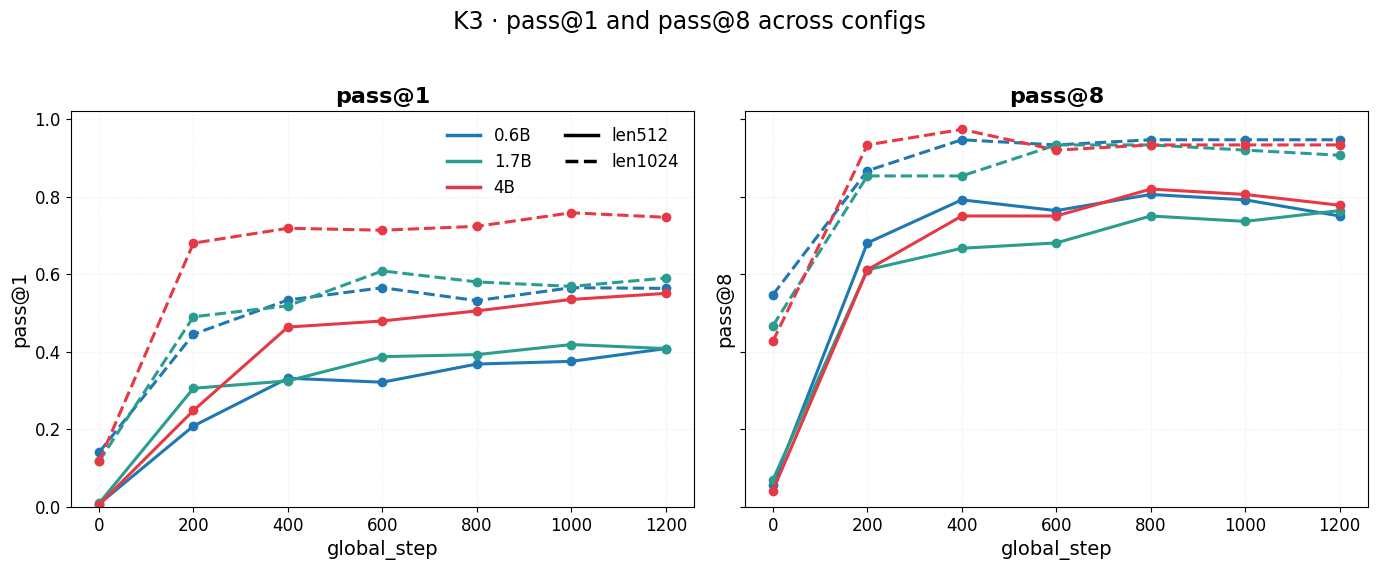


[pass@1 @ step=1200]
       len512  len1024
model                 
0.6B    0.408    0.563
1.7B    0.408    0.590
4B      0.550    0.747

[pass@4 @ step=1200]
       len512  len1024
model                 
0.6B    0.674    0.875
1.7B    0.676    0.838
4B      0.727    0.904

[pass@8 @ step=1200]
       len512  len1024
model                 
0.6B    0.750    0.947
1.7B    0.764    0.907
4B      0.778    0.933

[pass@8 - pass@1 (latent diversity) @ step=1200]
       len512  len1024
model                 
0.6B    0.342    0.383
1.7B    0.356    0.317
4B      0.227    0.187


In [5]:
from src.velo_viz import plot_pass_at_k

pak = {}
for cfg in CONFIGS:
    fig, _, info = plot_pass_at_k(DFS[cfg], verbose=False); plt.close(fig)
    pak[cfg] = info["pak_df"]  # cols: step, k, val, lo, hi

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), sharex=True, sharey=True)
for cfg, df in pak.items():
    m, L = cfg
    for ax, k in zip(axes, [1, 8]):
        sub = df[df.k == k]
        ax.plot(sub.step, sub.val, **style(m, L))
for ax, k in zip(axes, [1, 8]):
    ax.set(xlabel="global_step", ylabel=f"pass@{k}", title=f"pass@{k}", ylim=(0, 1.02))
    ax.grid(alpha=0.25, linestyle=":")
cross_legend(axes[0])
fig.suptitle("K3 · pass@1 and pass@8 across configs", y=1.02)
fig.tight_layout()
savefig(fig, "game24-k3.png")
plt.show()

def _pk(c, k):
    s = pak[c]; row = s[(s.step == FINAL_STEP) & (s.k == k)]
    return float(row.val.iloc[0]) if len(row) else float("nan")

k3_info = {
    "pass@1": cross_summary({c: _pk(c, 1) for c in CONFIGS}, "pass@1"),
    "pass@4": cross_summary({c: _pk(c, 4) for c in CONFIGS}, "pass@4"),
    "pass@8": cross_summary({c: _pk(c, 8) for c in CONFIGS}, "pass@8"),
    "pass@8 - pass@1": cross_summary({c: _pk(c, 8) - _pk(c, 1) for c in CONFIGS}, "pass@8 - pass@1 (latent diversity)"),
}

## Kernel 4 · Solution-coverage dynamics

Mirrors `plot_solution_coverage_dynamics`. We summarise three coverage signals at FINAL_STEP:

- **per-cycle diversity** — fraction of distinct canonical solutions emitted in this cycle.
- **cumulative coverage** — fraction of all canonical solutions ever found up to this step.
- **novel-fraction** — at this step, what fraction of the run's *ever-found* solutions were first emitted now (mode collapse → 0).

  saved manuscript/figures/game24-k4.png


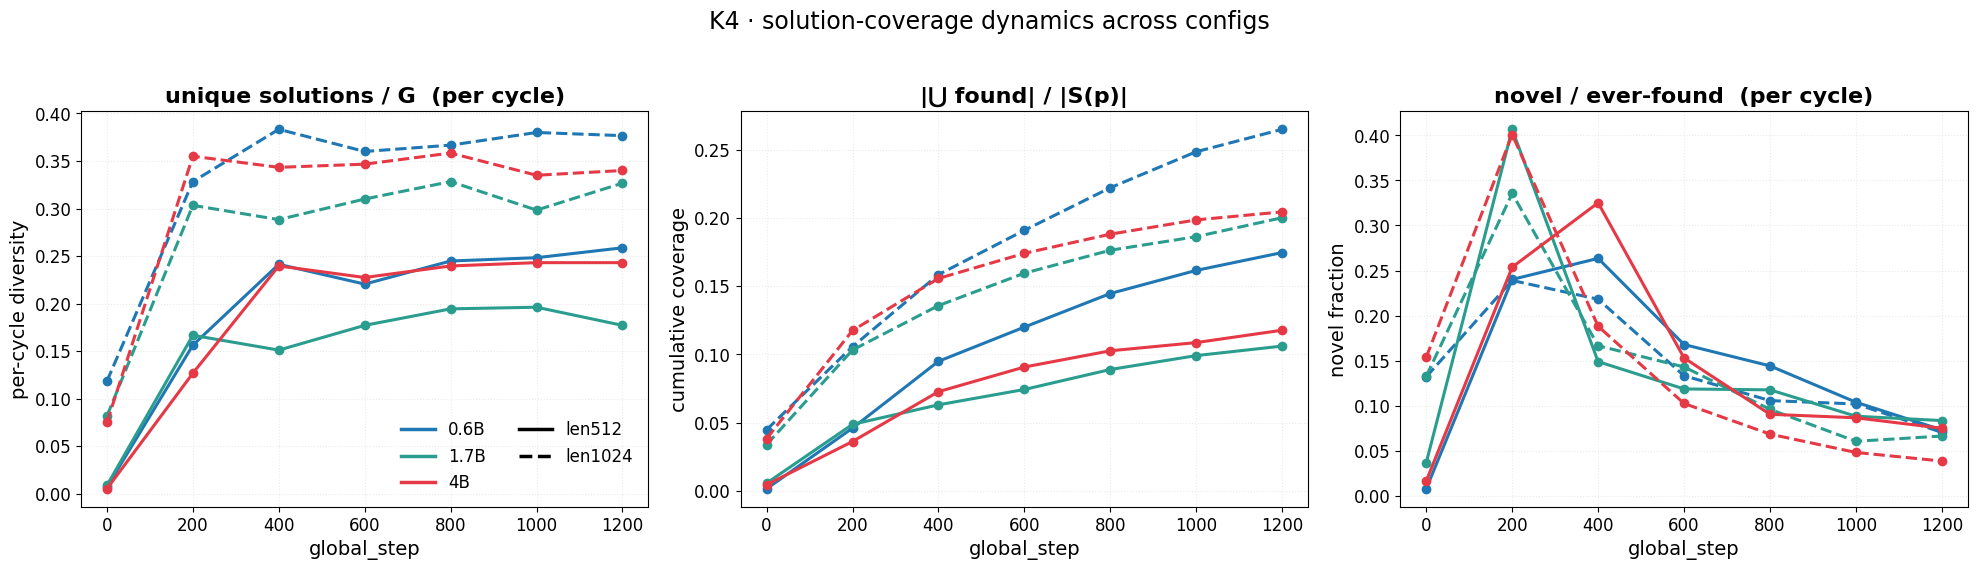


[per-cycle diversity @ step=1200]
       len512  len1024
model                 
0.6B    0.259    0.377
1.7B    0.177    0.327
4B      0.243    0.340

[cumulative coverage @ step=1200]
       len512  len1024
model                 
0.6B    0.175    0.265
1.7B    0.106    0.200
4B      0.118    0.205

[novel-fraction @ step=1200]
       len512  len1024
model                 
0.6B    0.073    0.070
1.7B    0.083    0.066
4B      0.075    0.038


In [6]:
from src.velo_viz import plot_solution_coverage_dynamics

cov = {}
for cfg in CONFIGS:
    fig, _, info = plot_solution_coverage_dynamics(DFS[cfg], verbose=False); plt.close(fig)
    cov[cfg] = info

def _summary(info, key):
    df = info[key]
    s = df.set_index("step")["val"] if "step" in df.columns else df.set_index("global_step")["val"]
    return s

fig, axes = plt.subplots(1, 3, figsize=(20, 5.6), sharex=True)
for cfg, info in cov.items():
    m, L = cfg
    s_cov   = _summary(info, "cov_mean")
    s_cum   = _summary(info, "cum_mean")
    s_novel = _summary(info, "novel_mean")
    axes[0].plot(s_cov.index,   s_cov.values,   **style(m, L))
    axes[1].plot(s_cum.index,   s_cum.values,   **style(m, L))
    axes[2].plot(s_novel.index, s_novel.values, **style(m, L))
axes[0].set(xlabel="global_step", ylabel="per-cycle diversity", title="unique solutions / G  (per cycle)")
axes[1].set(xlabel="global_step", ylabel="cumulative coverage", title="|\u22C3 found| / |S(p)|")
axes[2].set(xlabel="global_step", ylabel="novel fraction",      title="novel / ever-found  (per cycle)")
for ax in axes:
    ax.grid(alpha=0.25, linestyle=":")
cross_legend(axes[0])
fig.suptitle("K4 · solution-coverage dynamics across configs", y=1.02)
fig.tight_layout()
savefig(fig, "game24-k4.png")
plt.show()

def _last_cov(info, key):
    s = _summary(info, key)
    return float(s.loc[FINAL_STEP]) if FINAL_STEP in s.index else float("nan")

k4_info = {
    "per_cycle_div": cross_summary({c: _last_cov(cov[c], "cov_mean")   for c in CONFIGS}, "per-cycle diversity"),
    "cum_coverage":  cross_summary({c: _last_cov(cov[c], "cum_mean")   for c in CONFIGS}, "cumulative coverage"),
    "novel_frac":    cross_summary({c: _last_cov(cov[c], "novel_mean") for c in CONFIGS}, "novel-fraction"),
}

## Kernels 5 & 6 · Within-puzzle prefix sharing and $R_T$ correctness contrast

Two related diagnostics rendered side-by-side in a single row (next code cell after this one). K5 cell computes `pref` only; K6 cell adds `rt` and draws both panels.

- **K5 — prefix sharing** (`plot_prefix_sharing_dynamics`): top-1 share = fraction of the G rollouts within a puzzle that share the most-common 120-char prefix. Higher → more *prefix-collapsed*.
- **K6 — $R_T$ correctness contrast** (`plot_R_t_correctness_dynamics`): for configs that have `eval_rollout_vt.jsonl`, mean $R_T$ for *correct* vs *incorrect* rollouts at `FINAL_STEP`. The gap (correct − incorrect) measures how separable the two classes are under the trained policy's velocity reward.

In [7]:
from src.velo_viz import plot_prefix_sharing_dynamics

# K5 data only — combined K5+K6 figure is rendered in the next cell.
pref = {}
for cfg in CONFIGS:
    try:
        fig, _, info = plot_prefix_sharing_dynamics(DFS[cfg], verbose=False); plt.close(fig)
        pref[cfg] = info
    except Exception as e:
        print(f"  [skip] {cfg_label(*cfg)}: {e}")

def _last_top1(info):
    d = info["cov_mean_by_k"][1].set_index("step")["val"]
    return float(d.loc[FINAL_STEP]) if FINAL_STEP in d.index else float("nan")

k5_info = {
    "top1_prefix_share": cross_summary({c: _last_top1(pref[c]) for c in pref}, "top-1 prefix share"),
}


[top-1 prefix share @ step=1200]
       len512  len1024
model                 
0.6B    0.892    0.843
1.7B    0.788    0.637
4B      0.698    0.503


_(K6 data and the combined K5 + K6 figure are produced by the cell below.)_

  saved manuscript/figures/game24-k56.png


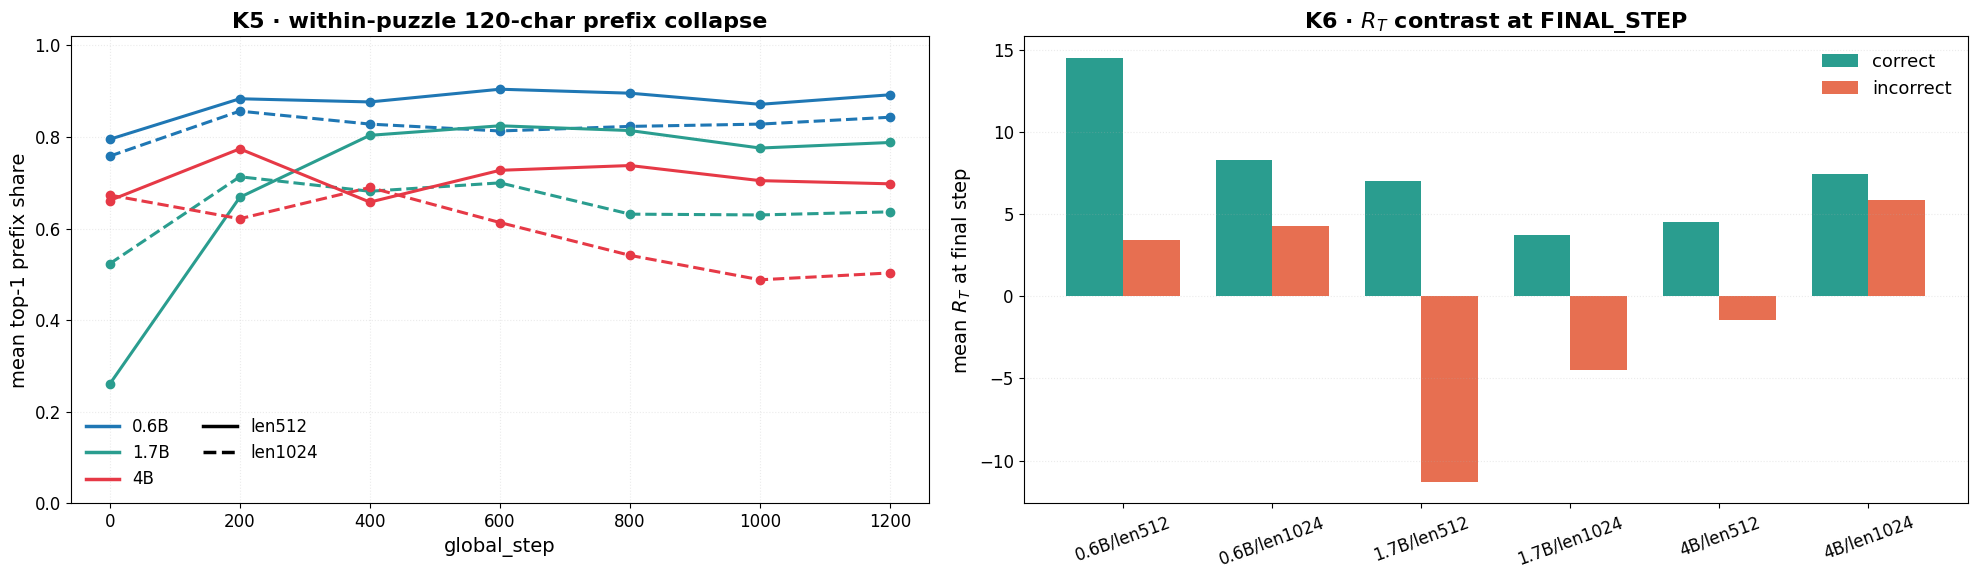


R_T summary:
              R_T_correct  R_T_incorrect  n_correct  n_incorrect    step
0.6B/len512        14.523          3.432      235.0        341.0  1200.0
0.6B/len1024        8.303          4.287      338.0        262.0  1200.0
1.7B/len512         7.039        -11.308      235.0        341.0  1200.0
1.7B/len1024        3.708         -4.471      354.0        246.0  1200.0
4B/len512           4.513         -1.454      317.0        259.0  1200.0
4B/len1024          7.426          5.871      448.0        152.0  1200.0

[R_T gap @ step=1200]
       len512  len1024
model                 
0.6B   11.091    4.017
1.7B   18.347    8.180
4B      5.967    1.555


In [8]:
from src.velo_viz import _vt_pick_ref

# K6 data
rt = {}
for cfg in CONFIGS:
    m, L = cfg
    p = cfg_dir(m, L) / "eval_rollout_vt.jsonl"
    if not p.exists():
        print(f"  [skip] {cfg_label(m, L)}: no vt sidecar"); continue
    rows = [json.loads(l) for l in p.read_text().splitlines() if l.strip()]
    if not rows:
        print(f"  [skip] {cfg_label(m, L)}: empty vt sidecar"); continue
    df = pd.DataFrame(rows)
    df["R_T"] = [_vt_pick_ref(r)[0] for r in rows]
    df = df[df["R_T"].notna()].copy()
    last = int(df.global_step.max())
    sub = df[df.global_step == last]
    rt[cfg] = {
        "R_T_correct":   float(sub.loc[sub.correct == True, "R_T"].mean()),
        "R_T_incorrect": float(sub.loc[sub.correct == False, "R_T"].mean()),
        "n_correct":     int((sub.correct == True).sum()),
        "n_incorrect":   int((sub.correct == False).sum()),
        "step":          last,
    }

# Combined K5 + K6 figure (single row, two panels).
fig, (ax5, ax6) = plt.subplots(1, 2, figsize=(20, 6.0),
                                gridspec_kw={"width_ratios": [1.0, 1.1]})

# --- K5: prefix collapse ---
for cfg, info in pref.items():
    m, L = cfg
    d = info["cov_mean_by_k"][1]
    ax5.plot(d.step, d.val, **style(m, L))
ax5.set(xlabel="global_step", ylabel="mean top-1 prefix share",
        title="K5 · within-puzzle 120-char prefix collapse",
        ylim=(0, 1.02))
ax5.grid(alpha=0.25, linestyle=":")
cross_legend(ax5)

# --- K6: R_T contrast bar chart ---
if rt:
    cfgs = list(rt.keys())
    labels = [cfg_label(*c) for c in cfgs]
    x = np.arange(len(cfgs)); w = 0.38
    ax6.bar(x - w/2, [rt[c]["R_T_correct"]   for c in cfgs], width=w, color="#2a9d8f", label="correct")
    ax6.bar(x + w/2, [rt[c]["R_T_incorrect"] for c in cfgs], width=w, color="#e76f51", label="incorrect")
    ax6.set_xticks(x); ax6.set_xticklabels(labels, rotation=20)
    ax6.set(ylabel="mean $R_T$ at final step",
            title="K6 · $R_T$ contrast at FINAL_STEP")
    ax6.grid(alpha=0.25, linestyle=":", axis="y")
    ax6.legend(loc="best", frameon=False)
else:
    ax6.text(0.5, 0.5, "no vt sidecars found in this sweep",
             ha="center", va="center", transform=ax6.transAxes)
    ax6.set_axis_off()

fig.tight_layout()
savefig(fig, "game24-k56.png")
plt.show()

if rt:
    print("\nR_T summary:")
    print(pd.DataFrame({cfg_label(*c): rt[c] for c in cfgs}).T.round(3).to_string())
    k6_info = {
        "R_T_gap (correct - incorrect)": cross_summary(
            {c: rt[c]["R_T_correct"] - rt[c]["R_T_incorrect"] for c in rt}, "R_T gap"),
    }
else:
    k6_info = {}

## Kernel 7 · Per-prefix-position $R_t$ correctness contrast

For each rollout we have the cumulative information-gain trajectory
$R_t = \log p_\theta(a \mid q, o_{1:t}) - \log p_\theta(a \mid q)$
sampled at a normalised position $\tau = t / T \in [0, 1]$. Using
`plot_R_t_correctness_dynamics`, we compute the *within-puzzle* correctness
contrast — for each puzzle that contains both correct and incorrect rollouts,
the per-position difference of the class means
$\Delta R_t = \overline{R_t}_{\text{correct}} - \overline{R_t}_{\text{incorrect}}$ —
and average over puzzles. This removes the puzzle-difficulty confound that the
naive correct-vs-incorrect overlay (panel (b) of that helper) inherits.

Reading: a curve that grows monotonically with $\tau$ means the velocity
signal accumulates *progressively* more correctness information as the CoT
unfolds; a curve that saturates early means the contrast is decided in the
first few tokens (prefix collapse, RQ3); a curve close to 0 means $R_t$ is
not class-discriminative at this scale of training.

  saved manuscript/figures/game24-k7.png


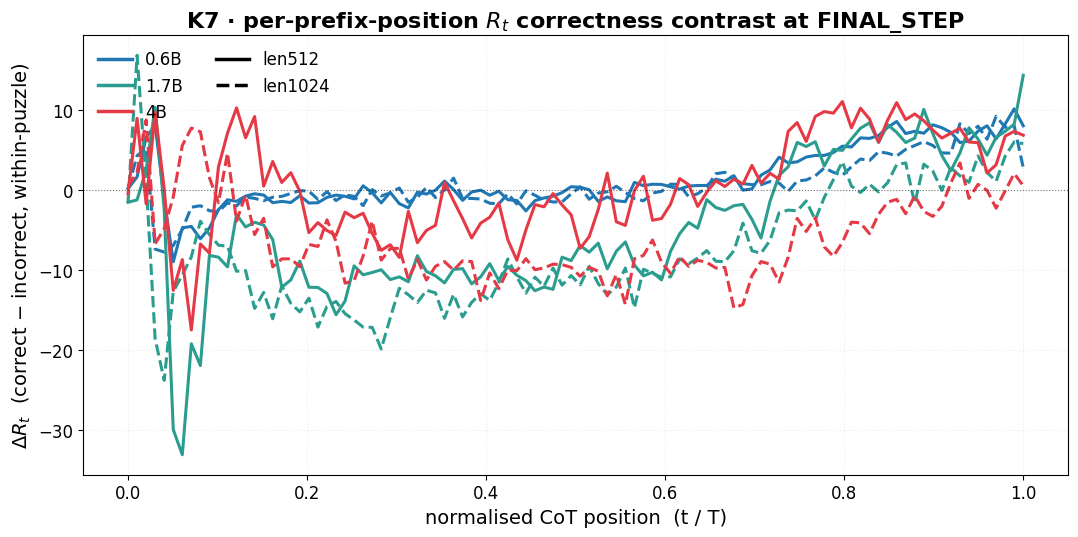


Within-puzzle ΔR_t summary:
              n_puzzles  ΔR_t @ τ=0.25  ΔR_t @ τ=0.50  ΔR_t @ τ=0.75  ΔR_t @ τ=1.00  ∫ ΔR_t dτ
cfg                                                                                           
0.6B/len512          50         -1.013          0.393          3.680          8.036      1.396
0.6B/len1024         64         -0.733         -0.029          1.168          2.798      0.717
1.7B/len512          48        -10.559         -7.866          5.827         14.339     -4.716
1.7B/len1024         50        -16.019        -11.253         -2.281          5.807     -7.832
4B/len512            38         -3.269         -5.171          7.845          6.852      0.698
4B/len1024           37        -11.380        -10.202         -3.935          0.551     -6.087

[ΔR_T at τ=1 (within-puzzle correctness contrast) @ step=1200]
       len512  len1024
model                 
0.6B    8.036    2.798
1.7B   14.339    5.807
4B      6.852    0.551


In [9]:
from src.velo_viz import plot_R_t_correctness_dynamics

rt_curves = {}
for cfg in CONFIGS:
    m, L = cfg
    p = cfg_dir(m, L) / "eval_rollout_vt.jsonl"
    if not p.exists():
        print(f"  [skip] {cfg_label(m, L)}: no vt sidecar"); continue
    try:
        fig_, _, info = plot_R_t_correctness_dynamics(p, verbose=False); plt.close(fig_)
    except Exception as e:
        print(f"  [skip] {cfg_label(m, L)}: {e}"); continue
    if info.get("mu_d") is None or len(info["contrast"]) == 0:
        print(f"  [skip] {cfg_label(m, L)}: no mixed-class puzzles"); continue
    rt_curves[cfg] = info

if not rt_curves:
    print("  no configs with mixed-class vt data — nothing to plot")
else:
    fig, ax = plt.subplots(figsize=(11, 5.6))
    for cfg, info in rt_curves.items():
        m, L = cfg
        n_pts = len(info["mu_d"])
        x = np.linspace(0.0, 1.0, n_pts)
        n_pz = len(info["contrast"])
        s = {**style(m, L), "marker": None}
        ax.plot(x, info["mu_d"],
                label=f"{cfg_label(m, L)}  (n={n_pz} pzls)",
                **s)
    ax.axhline(0, color="k", lw=0.8, ls=":", alpha=0.5)
    ax.set(xlabel="normalised CoT position  (t / T)",
           ylabel=r"$\Delta R_t$  (correct $-$ incorrect, within-puzzle)",
           title="K7 · per-prefix-position $R_t$ correctness contrast at FINAL_STEP")
    ax.grid(alpha=0.25, linestyle=":")
    cross_legend(ax, loc="upper left")
    fig.tight_layout()
    savefig(fig, "game24-k7.png")
    plt.show()

    # final-position Δ R as scalar summary (=R_T gap), and integral of the curve.
    summary_rows = []
    for cfg, info in rt_curves.items():
        mu = np.asarray(info["mu_d"], dtype=float)
        x  = np.linspace(0.0, 1.0, len(mu))
        summary_rows.append({
            "cfg":            cfg_label(*cfg),
            "n_puzzles":      len(info["contrast"]),
            "ΔR_t @ τ=0.25":  float(np.interp(0.25, x, mu)),
            "ΔR_t @ τ=0.50":  float(np.interp(0.50, x, mu)),
            "ΔR_t @ τ=0.75":  float(np.interp(0.75, x, mu)),
            "ΔR_t @ τ=1.00":  float(mu[-1]),
            "∫ ΔR_t dτ":      float(np.trapz(mu, x)),
        })
    print("\nWithin-puzzle ΔR_t summary:")
    print(pd.DataFrame(summary_rows).set_index("cfg").round(3).to_string())

    k7_info = {
        "ΔR_T (final pos, within-puzzle)": cross_summary(
            {c: float(rt_curves[c]["mu_d"][-1]) for c in rt_curves},
            "ΔR_T at τ=1 (within-puzzle correctness contrast)"),
    }

## Kernel 8 · Per-puzzle solution life-cycle (one figure per config)

For collaborator-facing slide review: we render the lifecycle "river"
(`plot_lifecycle_river`) for a single held-out puzzle across all six
(model, length) configs, using the same puzzle index everywhere so the
panels are directly comparable. Each lane = one unique CoT/expression;
thickness = number of rollouts that emitted it in a cycle; colour =
verifier verdict. The 6 PNGs are saved into `manuscript/figures/` and
also embedded as a 3x2 grid in the appendix of `main.tex`.


  saved manuscript/figures/game24-lifecycle-0.6B-len512.png


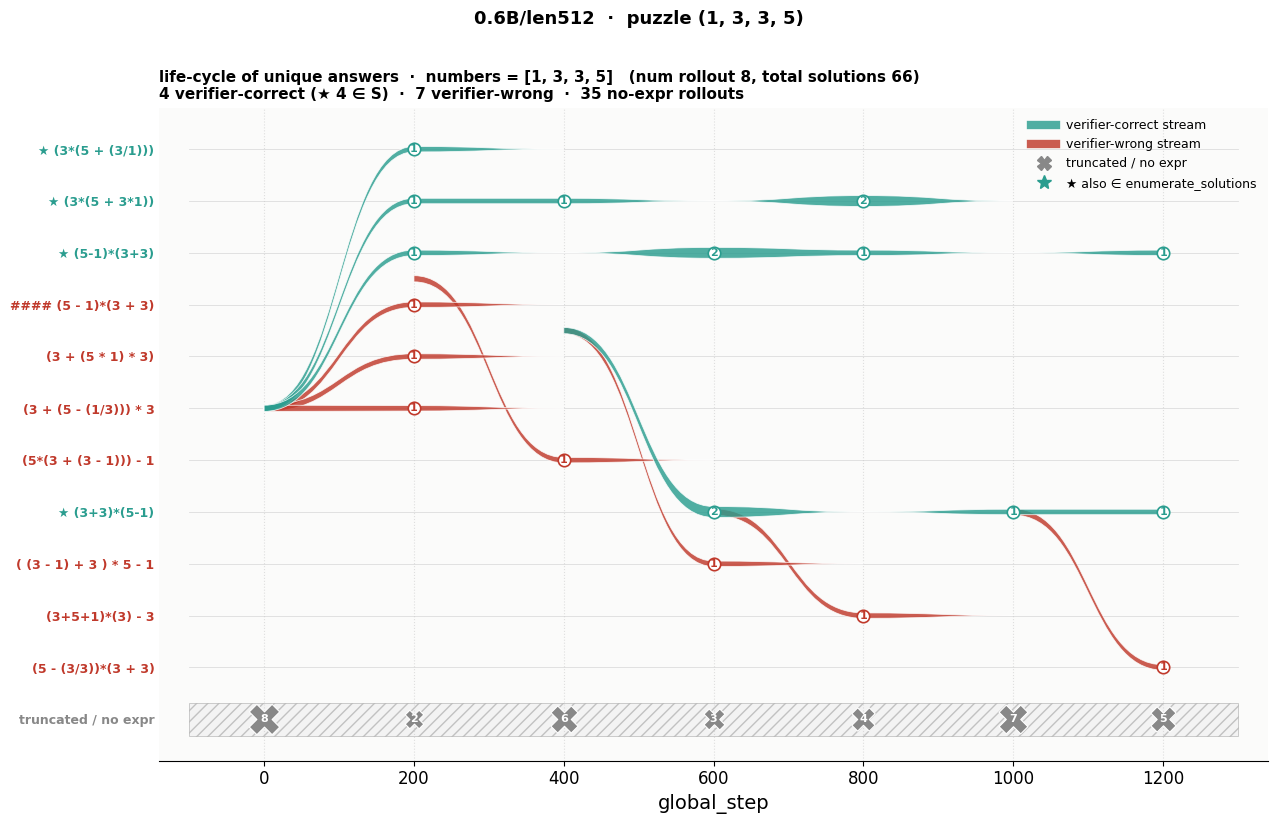

  saved manuscript/figures/game24-lifecycle-0.6B-len1024.png


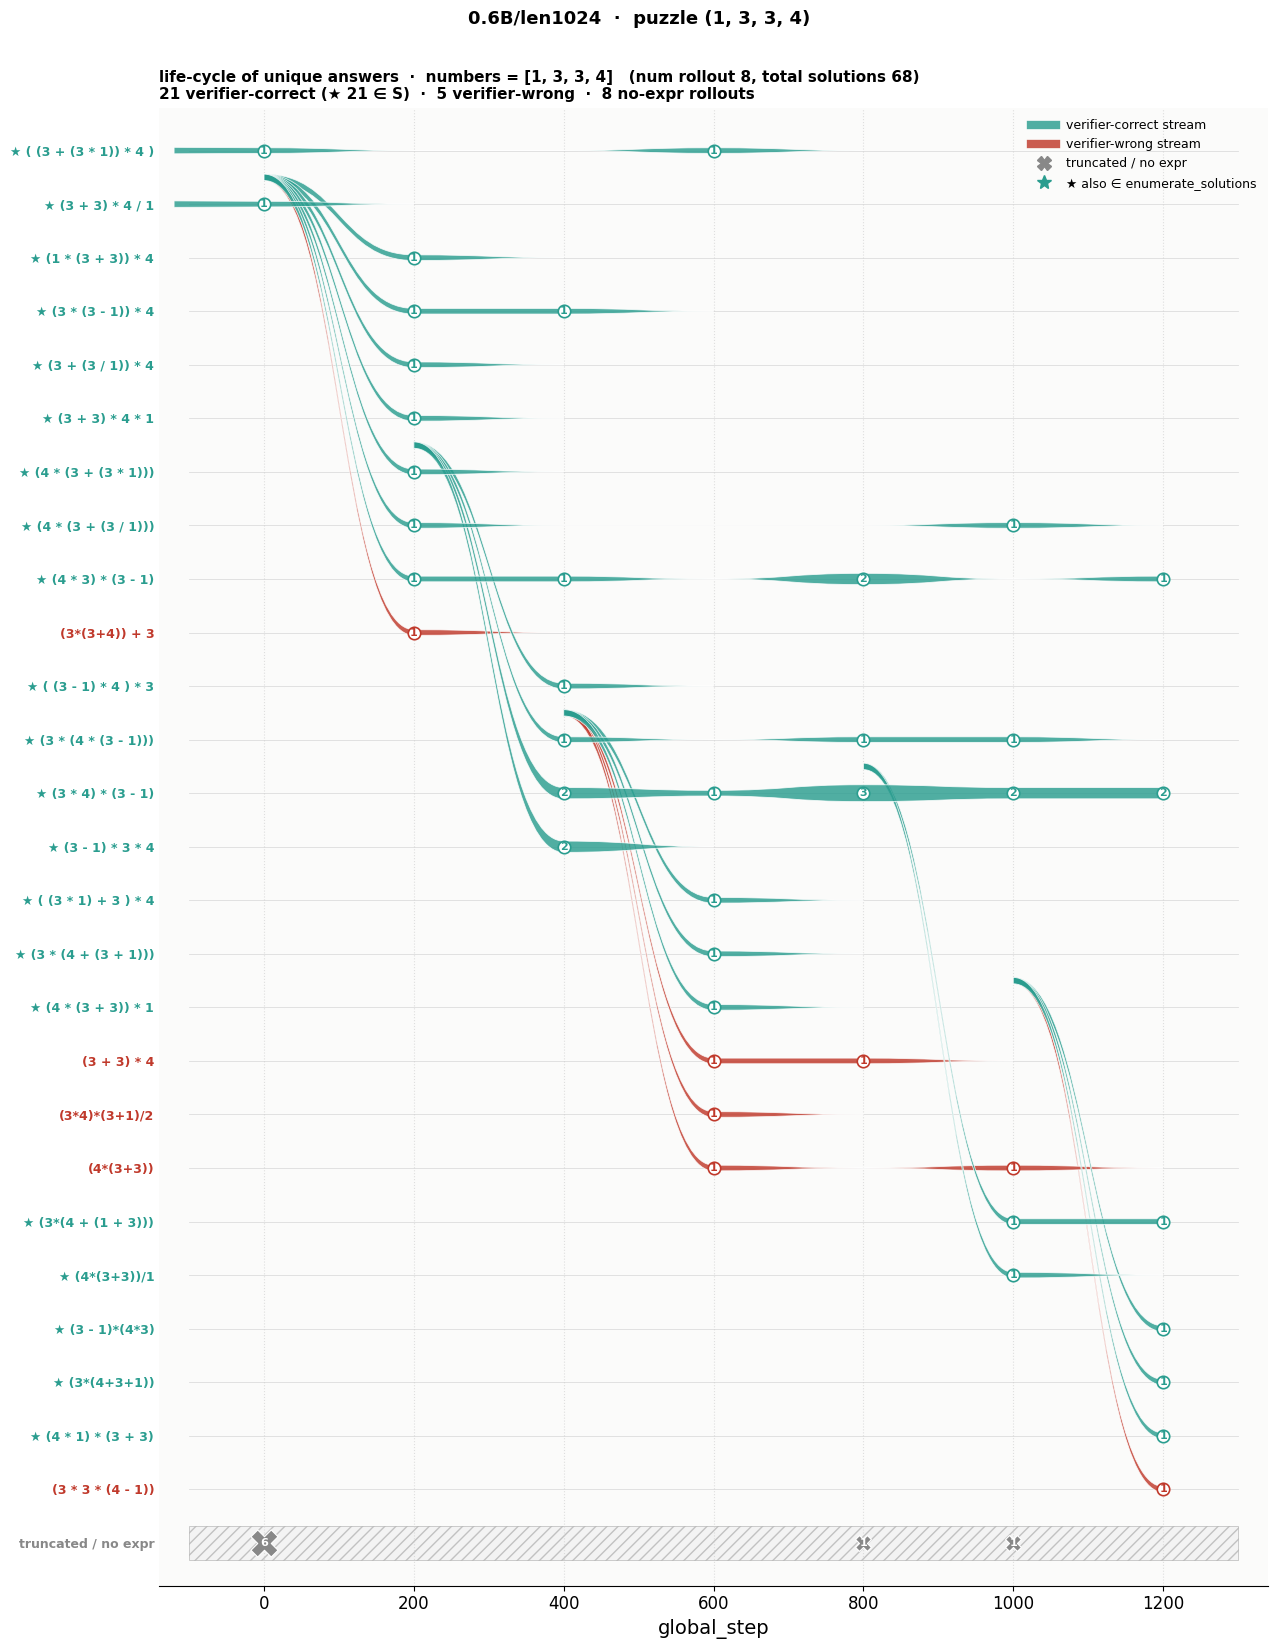

  saved manuscript/figures/game24-lifecycle-1.7B-len512.png


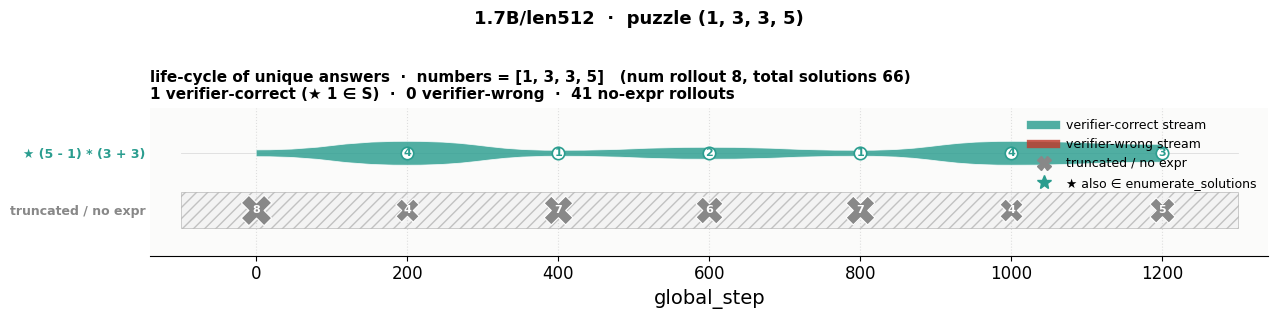

  saved manuscript/figures/game24-lifecycle-1.7B-len1024.png


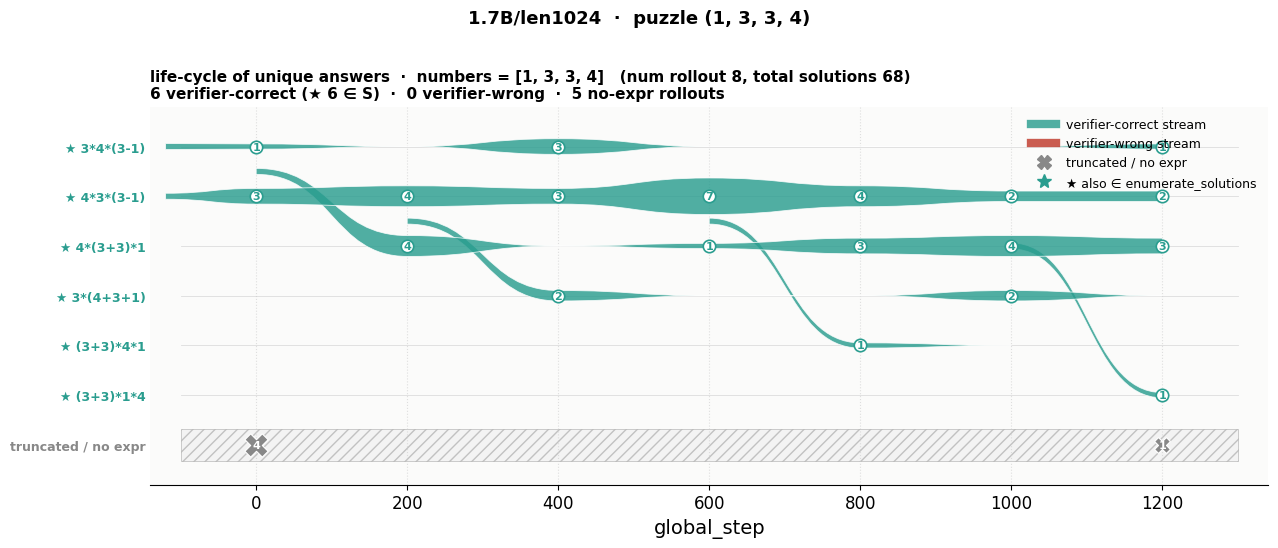

  saved manuscript/figures/game24-lifecycle-4B-len512.png


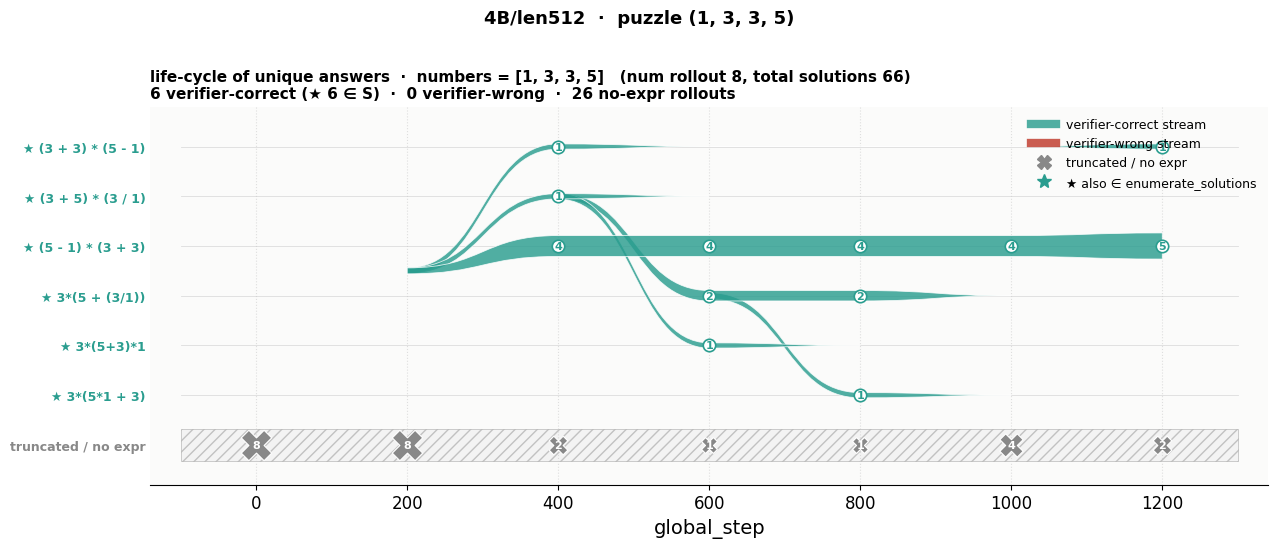

  saved manuscript/figures/game24-lifecycle-4B-len1024.png


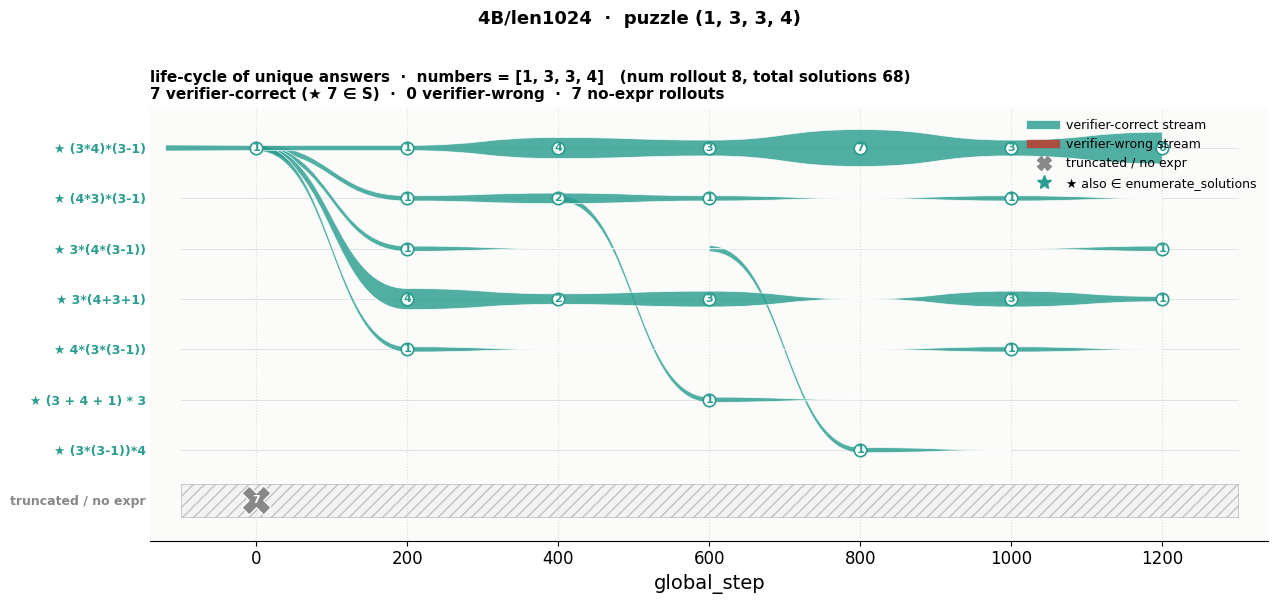

  wrote 72 lifecycle PNGs to output/figures/lifecycle/0.6B-len512
  wrote 75 lifecycle PNGs to output/figures/lifecycle/0.6B-len1024
  wrote 72 lifecycle PNGs to output/figures/lifecycle/1.7B-len512
  wrote 75 lifecycle PNGs to output/figures/lifecycle/1.7B-len1024
  wrote 72 lifecycle PNGs to output/figures/lifecycle/4B-len512
  wrote 75 lifecycle PNGs to output/figures/lifecycle/4B-len1024


In [10]:
from src.velo_viz import plot_lifecycle_river

PUZZLE_IDX = 11   # single puzzle reproduced in the manuscript appendix

# --- 1) one shared puzzle, all 6 configs --> manuscript/figures/ -----------
for cfg in CONFIGS:
    m, L = cfg
    df = DFS[cfg]
    keys = sorted(df.key.unique())
    if PUZZLE_IDX >= len(keys):
        print(f"  [skip] {cfg_label(m, L)}: only {len(keys)} puzzles"); continue
    nums = keys[PUZZLE_IDX]
    fig, _, _ = plot_lifecycle_river(df, idx=PUZZLE_IDX, verbose=False)
    fig.suptitle(f"{cfg_label(m, L)}  ·  puzzle {tuple(nums)}",
                 fontsize=13, fontweight="bold", y=1.0)
    fig.tight_layout()
    savefig(fig, f"game24-lifecycle-{MODEL_SHORT[m]}-len{L}.png")
    plt.show()

# --- 2) every val puzzle for every config --> output/figures/lifecycle/ ----
LIFE_DIR = Path("output/figures/lifecycle")
LIFE_DIR.mkdir(parents=True, exist_ok=True)

for cfg in CONFIGS:
    m, L = cfg
    df = DFS[cfg]
    keys = sorted(df.key.unique())
    sub_dir = LIFE_DIR / f"{MODEL_SHORT[m]}-len{L}"
    sub_dir.mkdir(parents=True, exist_ok=True)
    for i, nums in enumerate(keys):
        try:
            fig, _, _ = plot_lifecycle_river(df, idx=i, verbose=False)
        except Exception as e:
            print(f"  [skip] {cfg_label(m, L)} puzzle {tuple(nums)}: {e}")
            continue
        fig.suptitle(f"{cfg_label(m, L)}  ·  puzzle {tuple(nums)}",
                     fontsize=13, fontweight="bold", y=1.0)
        fig.tight_layout()
        slug = "-".join(str(n) for n in nums)
        out  = sub_dir / f"puzzle{i:02d}_{slug}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        plt.close(fig)
    print(f"  wrote {len(keys)} lifecycle PNGs to {sub_dir}")


## Cross-config synthesis

Below: model effect (average over lengths, varying model) and length effect (average over models, varying length) for the final-step metrics.

In [11]:
import textwrap

ALL = {**{f"K1·{k}": v for k, v in k1_info.items()},
       **{f"K2·{k}": v for k, v in k2_info.items()},
       **{f"K3·{k}": v for k, v in k3_info.items()},
       **{f"K4·{k}": v for k, v in k4_info.items()},
       **{f"K5·{k}": v for k, v in k5_info.items()},
       **{f"K6·{k}": v for k, v in k6_info.items()},
       **{f"K7·{k}": v for k, v in (k7_info if "k7_info" in dir() else {}).items()}}

rows = []
for name, mat in ALL.items():
    if mat is None or mat.empty: continue
    by_model = mat.mean(axis=1)   # average over lengths → effect of model
    by_len   = mat.mean(axis=0)   # average over models  → effect of length
    rows.append({
        "metric":           name,
        "0.6B":             float(by_model.get("0.6B", float("nan"))),
        "1.7B":             float(by_model.get("1.7B", float("nan"))),
        "4B":               float(by_model.get("4B",   float("nan"))),
        "\u0394(4B-0.6B)":  float(by_model.get("4B", np.nan) - by_model.get("0.6B", np.nan)),
        "len512":           float(by_len.get(512, float("nan"))),
        "len1024":          float(by_len.get(1024, float("nan"))),
        "\u0394(1024-512)": float(by_len.get(1024, np.nan) - by_len.get(512, np.nan)),
    })
synth = pd.DataFrame(rows).set_index("metric").round(3)
print("=== Cross-config synthesis at FINAL_STEP ===")
print("(model-effect: averaged over lengths;  length-effect: averaged over models)\n")
print(synth.to_string())

=== Cross-config synthesis at FINAL_STEP ===
(model-effect: averaged over lengths;  length-effect: averaged over models)

                                       0.6B     1.7B       4B  Δ(4B-0.6B)  len512  len1024  Δ(1024-512)
metric                                                                                                 
K1·mean_len_final                   553.279  577.725  496.339     -56.940     NaN      NaN          NaN
K1·pct_parsable_final                 0.578    0.559    0.675       0.097     NaN      NaN          NaN
K1·pct_correct_final                  0.486    0.499    0.649       0.163     NaN      NaN          NaN
K2·mean_len                         553.279  577.725  496.339     -56.940     NaN      NaN          NaN
K2·mean_len_correct                 406.629  440.966  386.309     -20.320     NaN      NaN          NaN
K2·mean_len_incorrect               709.590  736.770  742.930      33.339     NaN      NaN          NaN
K2·uniq_correct_per_pzl               3.885   

## Reading guide for the two questions

All numbers in the synthesis table are at `FINAL_STEP` (= last common eval cycle). Use Δ columns directly.

### Q1 · Effect of *model size* (Δ(4B − 0.6B), averaged over lengths)

| signal | where to look | reading |
|---|---|---|
| **rollout length** | `K1·mean_len_final`, `K2·mean_len_correct`, `K2·mean_len_incorrect` | sign of Δ(4B−0.6B): **negative** ⇒ bigger model makes the trained policy *shorter*; positive ⇒ longer. Split by correctness disentangles real reasoning compaction (Δ on `mean_len_correct`) from truncation pile-up (Δ on `mean_len_incorrect`, capped at max_len). |
| **CoT diversity** | `K2·uniq_correct_per_pzl`, `K4·per_cycle_div`, `K4·cum_coverage`, `K5·top1_prefix_share` | high uniq + high coverage + low top-1 prefix share ⇒ more diverse. **K5 negative Δ** ⇒ bigger model less prefix-collapsed. |
| **accuracy** | `K1·pct_correct_final`, `K3·pass@1`, `K3·pass@8`, `K3·pass@8 - pass@1` | Δ(4B−0.6B) > 0 on pass@1 = bigger model more accurate. The pass@8−pass@1 gap measures *latent* diversity even after conditioning on accuracy. |

### Q2 · Effect of *max_len* (Δ(1024 − 512), averaged over models)

| signal | reading |
|---|---|
| **rollout length** | If Δ on `K1·mean_len_final` ≈ 0 then GRPO has compressed away from the cap and the cap doesn't bind anymore. If Δ ≫ 0 the policy is still cap-limited at 512. Compare against `mean_len_incorrect` — if that Δ is large but `mean_len_correct` Δ is small, only the truncated/incorrect tail is being relieved. |
| **CoT diversity** | A larger max_len gives more headroom for branching; check `K4·cum_coverage` and `K5·top1_prefix_share`. Negative Δ on top1 share ⇒ longer budget reduces prefix collapse. |
| **accuracy** | Δ on `pass@1` and `pct_correct_final`. If Δ ≈ 0 the budget is not the bottleneck for this model size at this training horizon; if Δ > 0 the cap was hurting. |